<a href="https://colab.research.google.com/github/mentlana/Analysis-of-symbols-and-standards-in-Muse/blob/main/%D0%AD%D1%82%D0%B0%D0%BF_2%2C_3_%D0%9F%D0%BE%D1%81%D1%82%D1%80%D0%BE%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BA%D0%BE%D0%BB%D0%BB%D0%BE%D0%BA%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%B3%D1%80%D0%B0%D1%84%D0%B0_%D0%B8_%D0%BD%D0%B0_%D0%B5%D0%B3%D0%BE_%D0%BE%D1%81%D0%BD%D0%BE%D0%B2%D0%B5_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Этап 2. Построение коллокационного графа

Импорт необходимых библиотек

In [1]:
%pip install fa2
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from fa2 import ForceAtlas2
from community import community_louvain

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 71.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fa2: filename=fa2-1.1.2-cp312-cp312-linux_x86_64.whl size=664934 sha256=a1e11c3802890827b8fe716f0125aba7d90ee469ae1dc1311fa208ed7deb8c28
  Stored in directory: /root/.cache/pip/wheels/cc/f7/c2/781f021b42f554904813e6371bdf66ec75c51006e0b9405bc4
Successfully built fa2


Загрузка файла

In [2]:
df = pd.read_csv('muse_corpus_full.csv')
df['tokens'] = df['tokens_str'].apply(lambda x: x.split())
print(f"Загружено текстов: {len(df)}")

Загружено текстов: 106


Функция для подсчета коллокаций
Алгоритм проходит по тексту скользящим окном (window_size). В пределах этого окна все уникальные пары слов получают +1 к весу связи (вес отражает силу семантической близости).

In [3]:
def build_co_occurrence_graph(corpus, window_size=4, top_n=150):
    graph = nx.Graph()
    for word_list in corpus:
        if len(word_list) < 2:
            continue
        for i, focus_word in enumerate(word_list):
            if len(focus_word) < 2:
                continue
            window_start = max(0, i - window_size)
            window_end = min(len(word_list), i + window_size + 1)
            context_words = word_list[window_start:i] + word_list[i+1:window_end]
            for context_word in context_words:
                if len(context_word) < 2 or focus_word == context_word:
                    continue
                if graph.has_edge(focus_word, context_word):
                    graph[focus_word][context_word]['weight'] += 1
                else:
                    graph.add_edge(focus_word, context_word, weight=1)

    # Обрезка до топ-N узлов по степени
    if top_n is not None and top_n < graph.number_of_nodes():
        degrees = dict(graph.degree())
        top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:top_n]
        graph = graph.subgraph(top_nodes).copy()

    print(f"Граф построен: {graph.number_of_nodes()} узлов, {graph.number_of_edges()} рёбер")
    return graph

In [4]:
corpus = df['tokens'].tolist()
G = build_co_occurrence_graph(corpus, window_size=4, top_n=150)

Граф построен: 150 узлов, 2712 рёбер


Визуализация графа (без кластеризации)

Координаты сохранены в muse_positions.csv


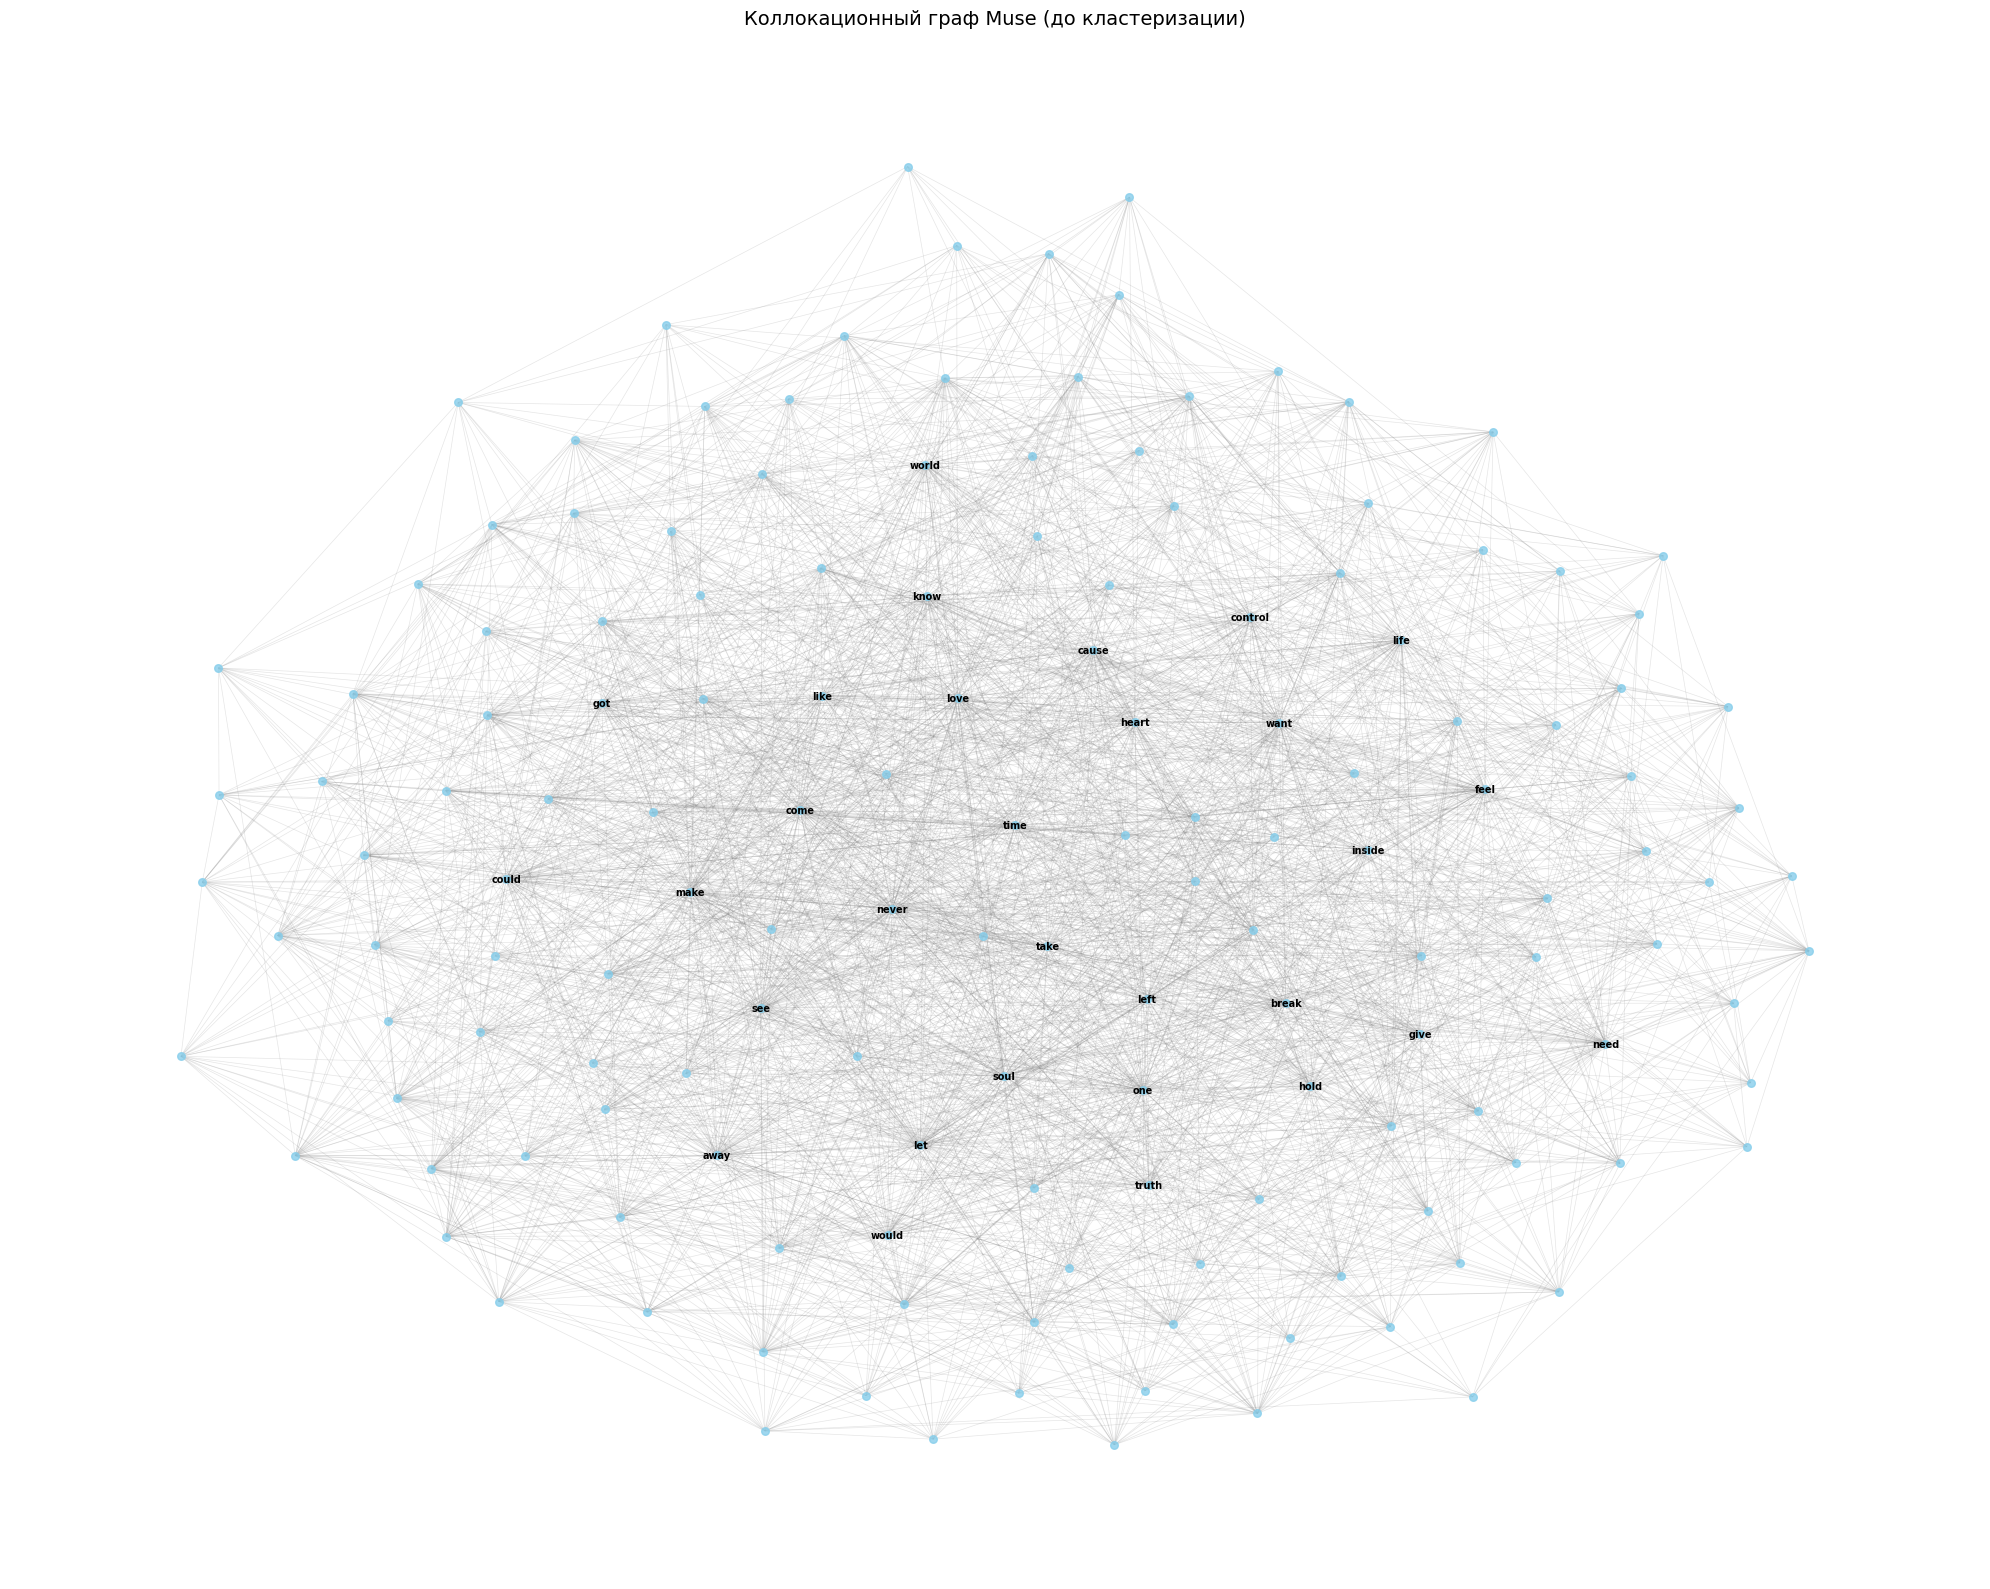

In [5]:
forceatlas2 = ForceAtlas2(
    outboundAttractionDistribution=False,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=0.5,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=2.0,
    strongGravityMode=False,
    gravity=1.0,
    verbose=False
)

positions = forceatlas2.forceatlas2_networkx_layout(G, pos=None, iterations=500)
pos_df = pd.DataFrame(positions).T.reset_index()
pos_df.columns = ['Id', 'x', 'y']
pos_df.to_csv('muse_positions.csv', index=False)
print("Координаты сохранены в muse_positions.csv")
# Отрисовка графа (без цветов кластеров)
plt.figure(figsize=(20, 16))
nx.draw_networkx_nodes(G, positions, node_size=30, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(G, positions, alpha=0.2, width=0.5, edge_color='gray')

# Метки для топ-30 узлов по степени
degrees = dict(G.degree())
top_nodes_labels = sorted(degrees, key=degrees.get, reverse=True)[:30]
nx.draw_networkx_labels(G, positions, {node: node for node in top_nodes_labels},
                        font_size=7, font_weight='bold')

plt.title("Коллокационный граф Muse (до кластеризации)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('muse_graph_before_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

# 3 этап. Кластерный анализ

Импорт необходимых библиотек

In [6]:
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from community import community_louvain
from collections import defaultdict

In [7]:
random.seed(42)
np.random.seed(42)

In [8]:
# Выделение сообществ (алгоритм Louvain)
communities = community_louvain.best_partition(G, random_state=42)
modularity = community_louvain.modularity(communities, G)

cluster_members = {}
for node, comm_id in communities.items():
    if comm_id not in cluster_members:
        cluster_members[comm_id] = []
    cluster_members[comm_id].append(node)

# Перенумерация кластеров от 0 до N-1 (по размеру: от большего к меньшему)
sorted_clusters = sorted(cluster_members.items(), key=lambda x: len(x[1]), reverse=True)
cluster_mapping = {old_id: new_id for new_id, (old_id, _) in enumerate(sorted_clusters)}
renumbered_members = {cluster_mapping[old_id]: members for old_id, members in cluster_members.items()}

# Сохраняем перенумерованный словарь для визуализации
renumbered_communities = {node: cluster_mapping[comm_id] for node, comm_id in communities.items()}

print("\nСостав кластеров")
for comm_id in sorted(renumbered_members.keys()):
    members = sorted(renumbered_members[comm_id])
    print(f"\nКластер {comm_id} (узлов: {len(members)}):")
    if len(members) > 20:
        print(f"  {', '.join(members[:20])}...")
    else:
        print(f"  {', '.join(members)}")

# Функция для получения внутренних связей кластера
def get_cluster_internal_edges(G, cluster_nodes):
    edges = []
    for u, v, data in G.edges(data=True):
        if u in cluster_nodes and v in cluster_nodes:
            edges.append((u, v, data['weight']))
    return sorted(edges, key=lambda x: x[2], reverse=True)

# Вывод топ-15 внутренних связей для каждого кластера
print("\nТоп 15 внутренних связей по кластерам")
for comm_id, members in sorted(renumbered_members.items()):
    members_set = set(members)
    internal_edges = get_cluster_internal_edges(G, members_set)
    print(f"\nКластер {comm_id} — топ 15 внутренних связей:")
    for u, v, w in internal_edges[:15]:
        print(f"  {u} – {v} (вес {w})")

# Визуализация графа с цветами кластеров
node_colors = [renumbered_communities[node] for node in G.nodes()]
plt.figure(figsize=(20, 16))

# Узлы с цветами по кластерам
nx.draw_networkx_nodes(G, positions, node_size=30, node_color=node_colors,
                       cmap=plt.cm.tab20, alpha=0.8)
nx.draw_networkx_edges(G, positions, alpha=0.15, width=0.5, edge_color='gray')

# Метки для топ 30 узлов по степени
if 'positions' in dir() or 'positions' in locals():
    degrees = dict(G.degree())
    top_nodes_labels = sorted(degrees, key=degrees.get, reverse=True)[:30]
    nx.draw_networkx_labels(G, positions, {node: node for node in top_nodes_labels},
                            font_size=7, font_weight='bold')

plt.title(f"Коллокационный граф Muse — {len(renumbered_members)} семантических кластеров\n"
          f"Модулярность: {modularity:.4f}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('muse_graph_after_clustering.png', dpi=300, bbox_inches='tight')
plt.close();
# plt.show()

# Сохранение результатов
community_df = pd.DataFrame([
    {'node': node, 'community': comm_id}
    for node, comm_id in renumbered_communities.items()
])
community_df.to_csv('muse_node_communities.csv', index=False, encoding='utf-8-sig')
print("\n Результаты сохранены в 'muse_node_communities.csv'")

# Сохраняем полные списки кластеров в TXT (без сокращений)
with open('muse_communities_list.txt', 'w', encoding='utf-8') as f:
    for comm_id in sorted(renumbered_members.keys()):
        members = sorted(renumbered_members[comm_id])
        f.write(f"\n=== Кластер {comm_id} (узлов: {len(members)}) ===\n")
        f.write(", ".join(members))
        f.write("\n")
print("Список сообществ сохранён в 'muse_communities_list.txt'")

# Дополнительно: сохраняем в Pickle для точного восстановления
import pickle
with open('muse_communities.pkl', 'wb') as f:
    pickle.dump(renumbered_communities, f)
print("Словарь communities сохранён в 'muse_communities.pkl'")


Состав кластеров

Кластер 0 (узлов: 31):
  another, around, break, breaking, chance, change, cold, control, dark, fall, feeling, free, game, got, heart, help, keep, lie, long, lose...

Кластер 1 (узлов: 27):
  afraid, alive, believe, black, broken, burn, cause, dead, die, feel, growing, hope, inside, left, life, light, like, nothing, seen, sky...

Кластер 2 (узлов: 24):
  alone, always, anymore, bring, coming, ever, everything, fear, give, gone, good, hold, home, human, leave, love, moment, much, need, pain...

Кластер 3 (узлов: 24):
  back, end, eye, fight, find, get, god, look, lost, must, pull, see, someone, strong, survive, tell, thing, thought, told, trapped...

Кластер 4 (узлов: 24):
  away, baby, come, could, destroy, erase, faith, falling, forget, go, hear, last, let, number, one, people, place, push, running, say...

Кластер 5 (узлов: 20):
  babe, behind, care, done, dream, drone, face, gon, hide, kill, killed, know, late, loved, make, memory, never, new, run, war

Топ 15 вну